#  Load Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv')
df.shape

/tmp/ipython-input-228158895.py:5: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv')


(34531, 151)

In [ ]:
df['loan_status'].value_counts()


,count
loan_status,
Fully Paid,21102
Charged Off,5416
Current,3262
Late (31-120 days),154
In Grace Period,72
Late (16-30 days),19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30025 entries, 0 to 30024
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 34.6+ MB


In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


#  Target Filtering

In [ ]:
df['loan_status'].value_counts()

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)

df['loan_status'].value_counts(), df['default'].value_counts()


(loan_status
 Fully Paid     21102
 Charged Off     5416
 Name: count, dtype: int64,
 default
 0    21102
 1     5416
 Name: count, dtype: int64)

#  Clean Messy Columns


In [ ]:
df['term'] = pd.to_numeric(
    df['term'].astype(str).str.replace(' months', '', regex=False),
    errors='coerce'
)

df['int_rate'] = pd.to_numeric(
    df['int_rate'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
)

df['emp_length'] = pd.to_numeric(
    df['emp_length'].astype(str).replace({
        '10+ years':'10','9 years':'9','8 years':'8','7 years':'7','6 years':'6',
        '5 years':'5','4 years':'4','3 years':'3','2 years':'2','1 year':'1','< 1 year':'0'
    }),
    errors='coerce'
)

df[['term','int_rate','emp_length']].head()


,term,int_rate,emp_length
0,36,13.99,10.0
1,36,11.99,10.0
2,60,10.78,10.0
4,60,22.45,3.0
5,36,13.44,4.0


#Data Quality Checks (Missing + Duplicates)

In [ ]:
df = df.drop(columns=df.columns[df.isna().mean() == 1.0])


In [ ]:
missing = df.isna().mean()
missing


,0
id,0.000000
loan_amnt,0.000000
funded_amnt,0.000000
funded_amnt_inv,0.000000
term,0.000000
...,...
settlement_date,0.966136
settlement_amount,0.966136
settlement_percentage,0.966136
settlement_term,0.966136


In [ ]:


df.duplicated().sum()


np.int64(0)

In [ ]:
X = df.drop(columns=['loan_status','default'], errors='ignore')
y = df['default']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category','bool']).columns

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


#Feature Distributions(EDA)

In [ ]:
corr = df.select_dtypes(include=['float64','int64']).corr(numeric_only=True)['default']
corr.sort_values(ascending=False).head(25)

,default
default,1.000000
recoveries,0.500713
collection_recovery_fee,0.497503
int_rate,0.317381
term,0.231646
hardship_dpd,0.200591
acc_open_past_24mths,0.136265
total_rec_late_fee,0.125412
hardship_amount,0.117854
num_tl_op_past_12m,0.112274


<Axes: xlabel='default'>

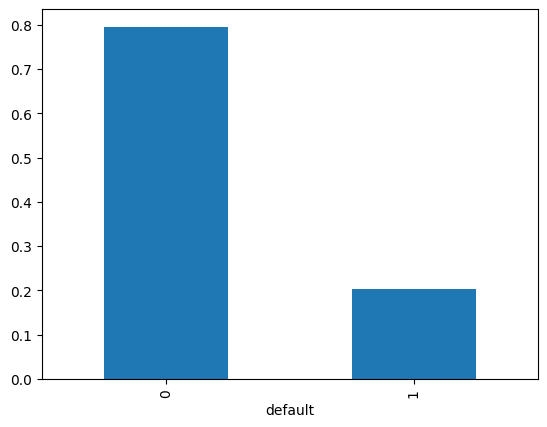

In [ ]:
df['default'].value_counts(normalize=True).plot(kind='bar')


array([[<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'int_rate'}>],
       [<Axes: title={'center': 'annual_inc'}>,
        <Axes: title={'center': 'dti'}>],
       [<Axes: title={'center': 'term'}>,
        <Axes: title={'center': 'installment'}>]], dtype=object)

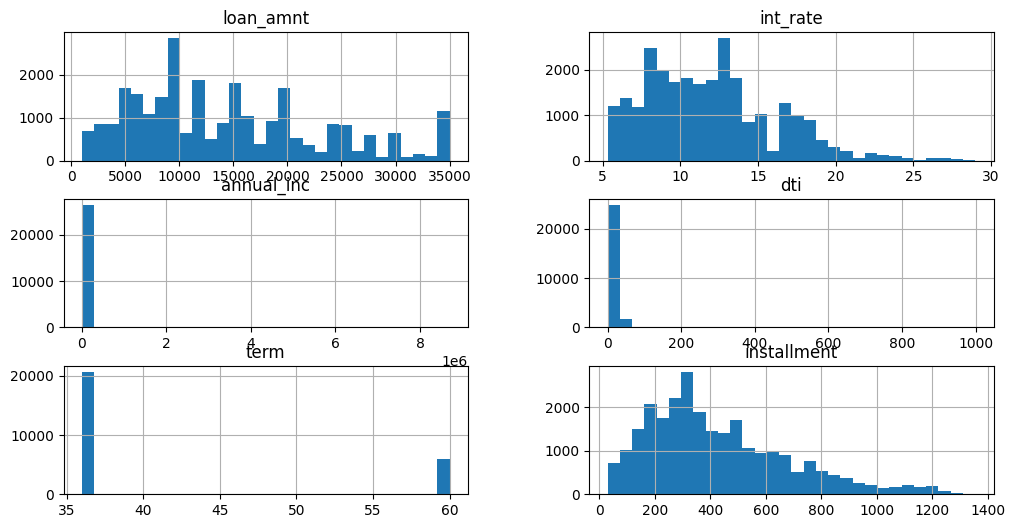

In [ ]:
cols = ['loan_amnt','int_rate','annual_inc','dti','term','installment']
df[cols].hist(bins=30, figsize=(12,6))


<Axes: title={'center': 'installment'}, xlabel='default'>

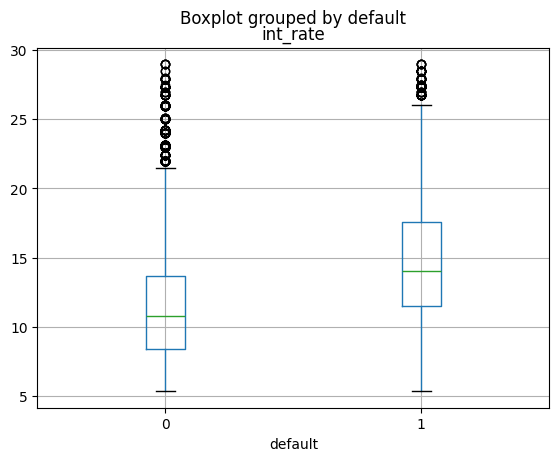

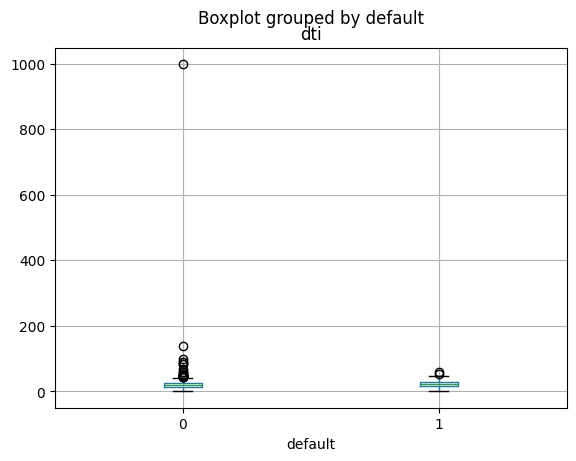

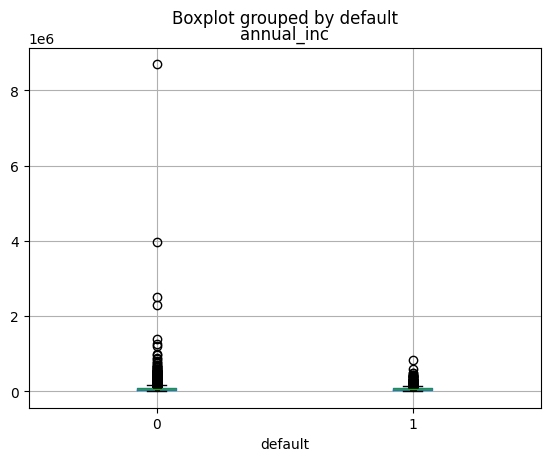

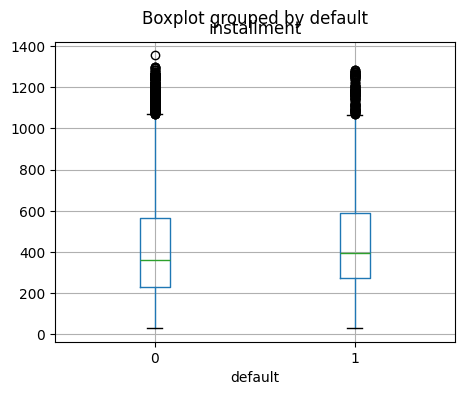

In [ ]:
df.boxplot(column='int_rate', by='default')
df.boxplot(column='dti', by='default')
df.boxplot(column='annual_inc', by='default')
df.boxplot(column='installment', by='default', figsize=(5,4))



In [ ]:
df['annual_inc'] = df['annual_inc'].clip(upper=df['annual_inc'].quantile(0.99))
df['dti'] = df['dti'].clip(upper=df['dti'].quantile(0.99))
df['installment'] = df['installment'].clip(upper=df['installment'].quantile(0.99))


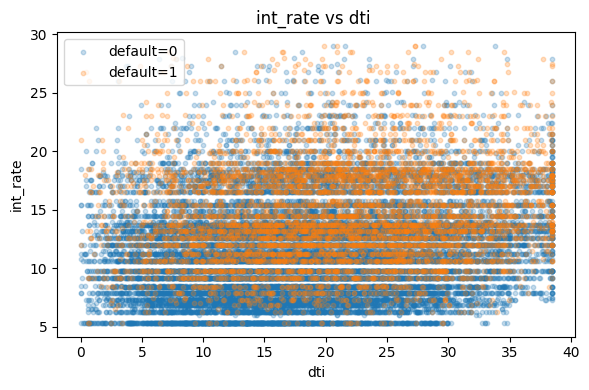

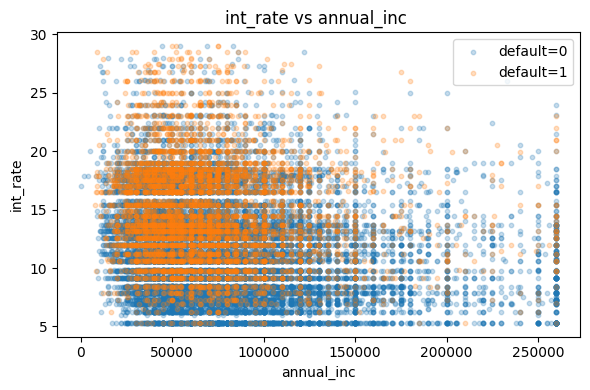

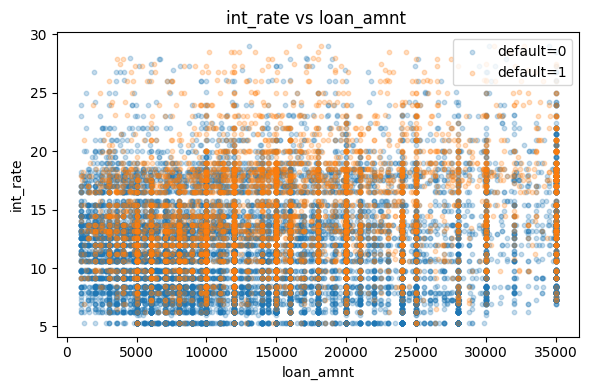

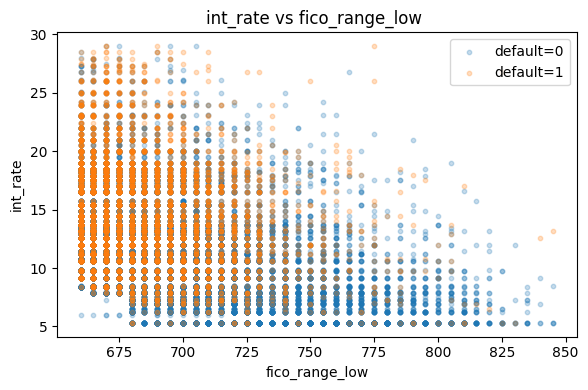

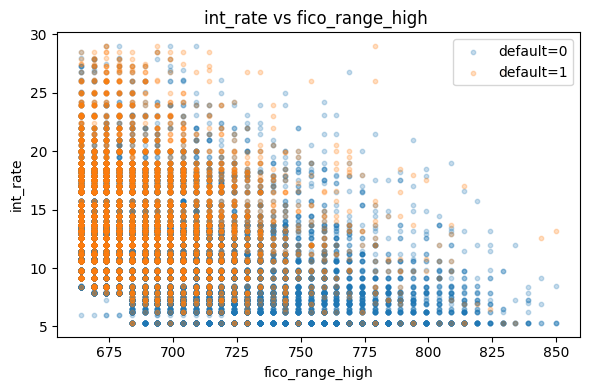

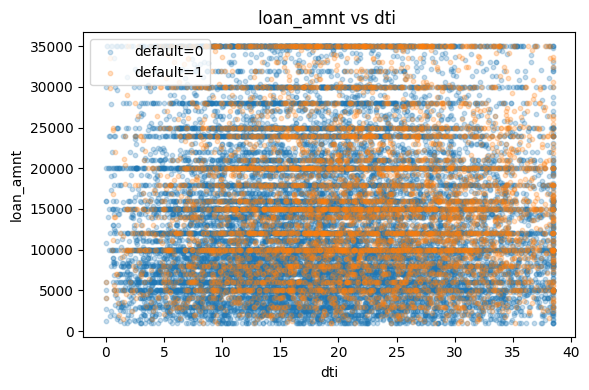

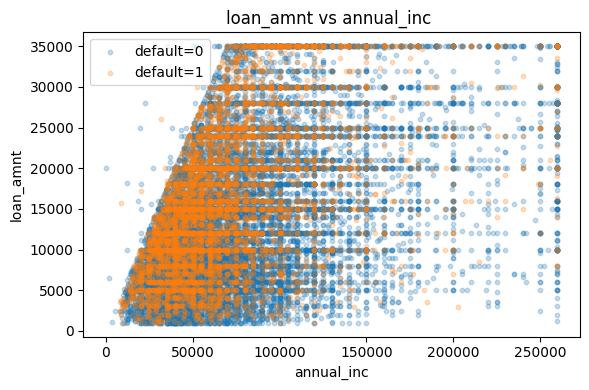

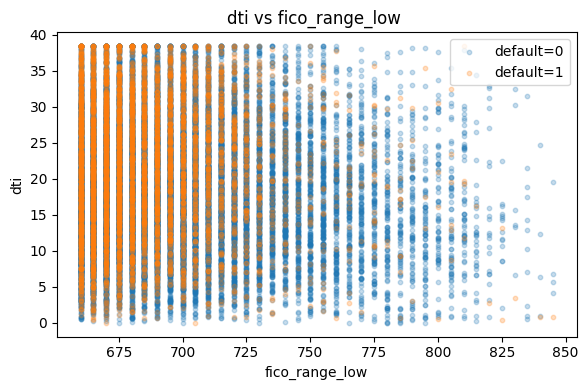

In [ ]:
import matplotlib.pyplot as plt

plot_cols = [
    ('dti', 'int_rate'),
    ('annual_inc', 'int_rate'),
    ('loan_amnt', 'int_rate'),
    ('fico_range_low', 'int_rate'),
    ('fico_range_high', 'int_rate'),
    ('dti', 'loan_amnt'),
    ('annual_inc', 'loan_amnt'),
    ('fico_range_low', 'dti'),
]

for xcol, ycol in plot_cols:
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6,4))
        plt.scatter(
            df.loc[df['default']==0, xcol],
            df.loc[df['default']==0, ycol],
            alpha=0.25, s=10, label='default=0'
        )
        plt.scatter(
            df.loc[df['default']==1, xcol],
            df.loc[df['default']==1, ycol],
            alpha=0.25, s=10, label='default=1'
        )
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f'{ycol} vs {xcol} ')
        plt.legend()
        plt.tight_layout()
        plt.show()

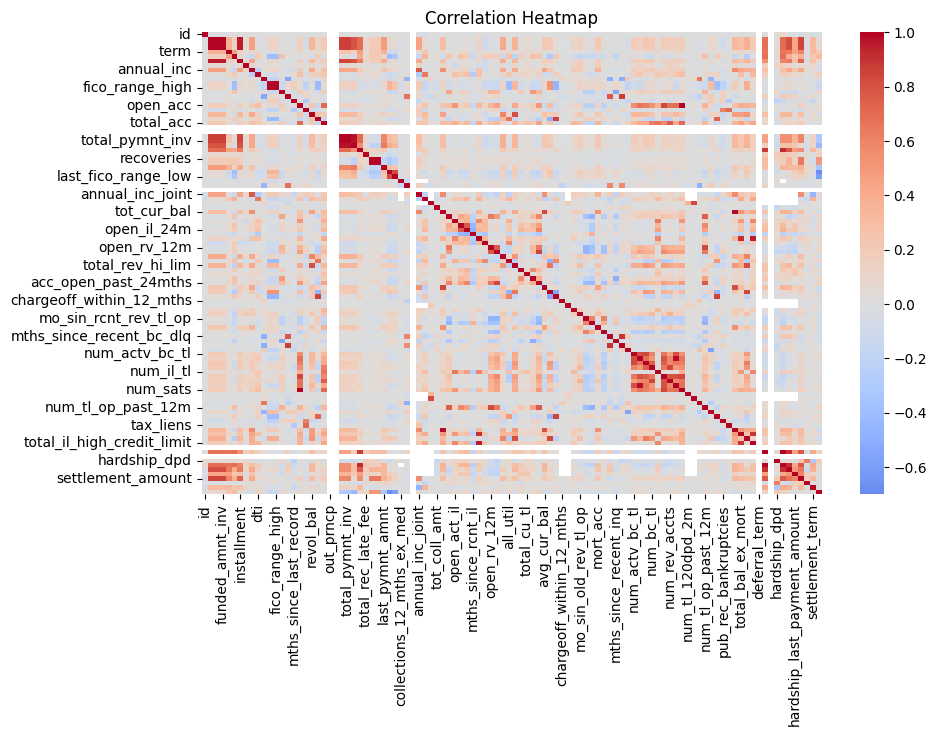

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=['float64','int64']).corr(),
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()


#train model+evalution
#leakage problem

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X = df.drop(columns=['loan_status', 'default'], errors='ignore').copy()
y = df['default'].copy()

X.columns = X.columns.astype(str)

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

ROC-AUC: 0.9976246345591631
PR-AUC: 0.9973313520380328
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1608
           1       0.99      0.99      0.99       388

    accuracy                           1.00      1996
   macro avg       0.99      0.99      0.99      1996
weighted avg       1.00      1.00      1.00      1996



In [ ]:
corr = df.select_dtypes(include=['float64','int64']).corr()['default'].sort_values(ascending=False)
corr.head(15)

,default
default,1.000000
recoveries,0.505817
collection_recovery_fee,0.501014
int_rate,0.315634
hardship_dpd,0.265270
term,0.223252
total_rec_late_fee,0.165198
acc_open_past_24mths,0.138078
dti,0.130668
open_rv_24m,0.116909


In [ ]:
leak_cols = [
    'recoveries',
    'collection_recovery_fee',
    'hardship_dpd',
    'hardship_amount',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'total_rec_late_fee',
    'total_rec_int',
    'total_rec_prncp',
    'last_fico_range_high',
    'settlement_date',
    'debt_settlement_flag_date'
]

df_noleak = df.drop(columns=leak_cols, errors='ignore').copy()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X = df_noleak.drop(columns=['loan_status', 'default'], errors='ignore').copy()
y = df_noleak['default'].copy()

X.columns = X.columns.astype(str)

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))


ROC-AUC: 0.9968376545109504
PR-AUC: 0.9952771032736955
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1608
           1       0.98      0.98      0.98       388

    accuracy                           0.99      1996
   macro avg       0.99      0.99      0.99      1996
weighted avg       0.99      0.99      0.99      1996



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(
    clf, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

pr_scores = cross_val_score(
    clf, X, y,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

print("ROC-AUC CV mean:", roc_scores.mean())
print("ROC-AUC CV std :", roc_scores.std())

print("PR-AUC CV mean:", pr_scores.mean())
print("PR-AUC CV std :", pr_scores.std())


ROC-AUC CV mean: 0.9978207270421736
ROC-AUC CV std : 0.0011829333730795654
PR-AUC CV mean: 0.9945097190488663
PR-AUC CV std : 0.0016686289215390572


#feature importence

In [ ]:
import numpy as np
import pandas as pd

prep  = clf.named_steps["prep"]
model = clf.named_steps["model"]

num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object","category","bool"]).columns.tolist()

feature_names = []
feature_names += num_cols

if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    feature_names += list(ohe.get_feature_names_out(cat_cols))

coefs = model.coef_.ravel()

fi_lr = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

fi_lr.head(25)





,feature,coef,abs_coef
25,last_pymnt_amnt,-5.635047,5.635047
23,total_pymnt,-5.537865,5.537865
24,total_pymnt_inv,-5.530819,5.530819
6,installment,3.056884,3.056884
3,funded_amnt_inv,2.487545,2.487545
1,loan_amnt,2.479527,2.479527
2,funded_amnt,2.479527,2.479527
14107,last_pymnt_d_Jan-2019,-2.159408,2.159408
26,last_fico_range_low,-1.745068,1.745068
14099,last_pymnt_d_Dec-2018,-1.495637,1.495637


In [ ]:
leak_cols = [

    'total_pymnt',
    'total_pymnt_inv',
    'last_pymnt_amnt',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',

    'recoveries',
    'collection_recovery_fee',
    'debt_settlement_flag',
    'settlement_status',
    'settlement_date',

    'last_pymnt_d',
    'last_credit_pull_d',

    'hardship_dpd',
    'hardship_amount',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest'

]
df_clean2 = df.drop(columns=leak_cols, errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X = df_clean2.drop(columns=['loan_status', 'default'], errors='ignore').copy()
y = df_clean2['default'].copy()

X.columns = X.columns.astype(str)

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

ROC-AUC: 0.9634303964243425
PR-AUC: 0.8719201370285525
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1012
           1       0.73      0.86      0.79       237

    accuracy                           0.91      1249
   macro avg       0.85      0.89      0.87      1249
weighted avg       0.92      0.91      0.92      1249



#benchmark model (logistic regression and Random forest)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

X = df_clean2.drop(columns=['loan_status','default'], errors='ignore')
y = df_clean2['default']

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category','bool']).columns

X[cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    clf = Pipeline([
        ('prep', preprocess),
        ('model', model)
    ])

    clf.fit(X_train, y_train)

    proba = clf.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, proba),
        "PR_AUC": average_precision_score(y_test, proba)
    })

benchmark = pd.DataFrame(results)
benchmark

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.963430,0.871920
1,Random Forest,0.957539,0.854589


#try oversampling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

X = df_clean2.drop(columns=['loan_status','default'], errors='ignore').copy()
y = df_clean2['default'].copy()

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category','bool']).columns
X[cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)

if hasattr(X_train_p, "toarray"):
    X_train_p = X_train_p.toarray()
    X_test_p  = X_test_p.toarray()


smote = SMOTE(random_state=42)
X_train_os, y_train_os = smote.fit_resample(X_train_p, y_train)

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_os, y_train_os)

proba = lr.predict_proba(X_test_p)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

ROC-AUC: 0.9633136538750188
PR-AUC: 0.870547995770496
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1012
           1       0.74      0.82      0.78       237

    accuracy                           0.91      1249
   macro avg       0.85      0.88      0.86      1249
weighted avg       0.92      0.91      0.91      1249



#try Regression to fill  Missing values  

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge


X = df_clean2.drop(columns=["loan_status", "default"], errors="ignore").copy()
y = df_clean2["default"].copy()

X.columns = X.columns.astype(str)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe_median = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_median = ColumnTransformer([
    ("num", num_pipe_median, num_cols),
    ("cat", cat_pipe, cat_cols)
])

clf_median = Pipeline([
    ("prep", preprocess_median),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

clf_median.fit(X_train, y_train)

proba_med = clf_median.predict_proba(X_test)[:, 1]
pred_med  = (proba_med >= 0.5).astype(int)

print(" Median Imputation")
print("ROC-AUC:", roc_auc_score(y_test, proba_med))
print("PR-AUC :", average_precision_score(y_test, proba_med))
print(classification_report(y_test, pred_med))



num_pipe_reg = Pipeline([
    ("imputer", IterativeImputer(
        estimator=BayesianRidge(),
        random_state=42,
        max_iter=10
    )),
    ("scaler", StandardScaler())
])

preprocess_reg = ColumnTransformer([
    ("num", num_pipe_reg, num_cols),
    ("cat", cat_pipe, cat_cols)
])

clf_reg = Pipeline([
    ("prep", preprocess_reg),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

clf_reg.fit(X_train, y_train)

proba_reg = clf_reg.predict_proba(X_test)[:, 1]
pred_reg  = (proba_reg >= 0.5).astype(int)

print("\n Regression Imputation ")
print("ROC-AUC:", roc_auc_score(y_test, proba_reg))
print("PR-AUC :", average_precision_score(y_test, proba_reg))
print(classification_report(y_test, pred_reg))

 Median Imputation
ROC-AUC: 0.9634303964243425
PR-AUC : 0.8719201370285525
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1012
           1       0.73      0.86      0.79       237

    accuracy                           0.91      1249
   macro avg       0.85      0.89      0.87      1249
weighted avg       0.92      0.91      0.92      1249


 Regression Imputation 
ROC-AUC: 0.963626357132136
PR-AUC : 0.8459580017744426
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1012
           1       0.72      0.87      0.79       237

    accuracy                           0.91      1249
   macro avg       0.85      0.90      0.87      1249
weighted avg       0.92      0.91      0.91      1249



#try to use orgnization time feature(just a try)

In [ ]:
leak_cols = [
    'recoveries',
    'collection_recovery_fee',
    'hardship_dpd',
    'hardship_amount',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'total_rec_late_fee',
    'total_rec_int',
    'total_rec_prncp',
    'last_fico_range_high',
    'settlement_date',
    'debt_settlement_flag_date'
]

df_noleak = df.drop(columns=leak_cols, errors='ignore').copy()

keep_cols = [
    'loan_amnt',
    'term',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_range_low',
    'fico_range_high',
    'installment',
    'acc_open_past_24mths',
    'inq_last_6mths',
    'num_tl_op_past_12m',
    'percent_bc_gt_75',
    'emp_length',
    'grade',
    'home_ownership'
]

keep_cols = [c for c in keep_cols if c in df_noleak.columns]

df_clean = df_noleak[keep_cols + ['default']].copy()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X = df_clean.drop(columns=['default']).copy()
y = df_clean['default'].copy()

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=4000, class_weight='balanced'))
])

clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

ROC-AUC: 0.7369549905391388
PR-AUC: 0.4161860115778166
              precision    recall  f1-score   support

           0       0.89      0.67      0.76     55314
           1       0.34      0.68      0.45     13984

    accuracy                           0.67     69298
   macro avg       0.62      0.67      0.61     69298
weighted avg       0.78      0.67      0.70     69298



#thresholds tuning

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.05, 0.95, 0.05)

rows = []

for t in thresholds:
    preds = (proba >= t).astype(int)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, preds, labels=[1], average=None
    )

    rows.append({
        "threshold": t,
        "precision": p[0],
        "recall": r[0],
        "f1": f[0]
    })

th_df = pd.DataFrame(rows)
th_df

,threshold,precision,recall,f1
0,0.05,0.201810,1.000000,0.335843
1,0.10,0.203887,0.999213,0.338670
2,0.15,0.212164,0.992563,0.349600
3,0.20,0.224942,0.976545,0.365657
4,0.25,0.238395,0.954519,0.381508
5,0.30,0.252428,0.923627,0.396494
6,0.35,0.270615,0.886871,0.414692
7,0.40,0.290250,0.829591,0.430041
8,0.45,0.312452,0.759010,0.442674
9,0.50,0.339814,0.677417,0.452593


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X = df_clean.drop(columns=['default']).copy()
y = df_clean['default'].copy()

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

if len(cat_cols) > 0:
    X.loc[:, cat_cols] = X[cat_cols].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

clf = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=4000, class_weight='balanced'))
])

clf.fit(X_train, y_train)

best_thresholds  = 0.55
pred = (proba >= best_thresholds).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

ROC-AUC: 0.7369549905391388
PR-AUC: 0.4161860115778166
              precision    recall  f1-score   support

           0       0.88      0.75      0.81     55314
           1       0.37      0.59      0.45     13984

    accuracy                           0.72     69298
   macro avg       0.62      0.67      0.63     69298
weighted avg       0.78      0.72      0.74     69298

